Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89        55
           1       1.00      0.22      0.36        18

    accuracy                           0.81        73
   macro avg       0.90      0.61      0.63        73
weighted avg       0.85      0.81      0.76        73

Accuracy: 80.82 %


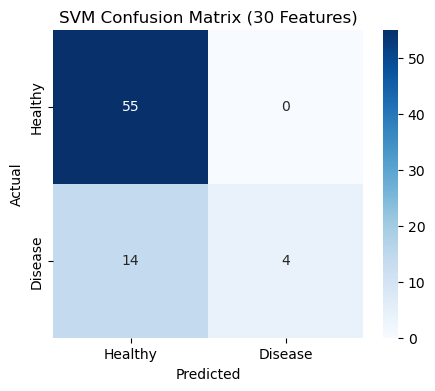

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt


mfcc_df = pd.read_csv("mfcc_cyst_dataset.csv")
tf_df = pd.read_csv("cyst_TF_features.csv")


if 'Filename' in tf_df.columns:
    tf_df = tf_df.drop(columns=["Filename"])


merged_df = pd.concat([mfcc_df.drop(columns=['Label']), tf_df], axis=1)


merged_df['Label'] = mfcc_df['Label']


X = merged_df.drop(columns=['Label'])
y = merged_df['Label']


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


svm = SVC(kernel='rbf', C=1, gamma='scale')
svm.fit(X_train, y_train)


y_pred = svm.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Accuracy:", round(accuracy_score(y_test, y_pred)*100, 2), "%")


cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', 'Disease'], yticklabels=['Healthy', 'Disease'])
plt.title("SVM Confusion Matrix (30 Features)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()
